 # Data Exploration

## Library imports and functions

In [198]:
import os
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import plotly.graph_objects as go

%matplotlib inline

MAX_SHORT: int = 2   # 2 samples x 15 min = 30 min
MAX_MEDIUM: int = 4  # 4 samples x 15 min = 1 h
WINDOW: int = 16      # valid samples used on each side of a gap

def process_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Resample the DataFrame to the specified frequency, identify outliers using IQR,
    and replace negative values with NaN.

    Parameters:
        df (pd.DataFrame): Input DataFrame with a datetime index.

    Returns:
        pd.DataFrame: Processed DataFrame with outliers and negative values replaced by NaN.
    """

    # Calculate IQR-based outliers
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Replace negative values with NaN
    df_cleaned = df.mask(df < 0)

    # Replace outliers with NaN
    df_cleaned = df_cleaned.mask((df_cleaned < lower_bound) | (df_cleaned > upper_bound))

    # # Replace outliers and negative values with NaN
    # df_cleaned = df.mask((df < lower_bound) | (df > upper_bound))
    # df_cleaned = df_cleaned.mask(df_cleaned < 0)

    return df_cleaned


def mask_gaps(df: pd.DataFrame, min_len: int = 0, max_len: int = None) -> pd.DataFrame:
    """
    Create a mask for gaps (NaN runs) in the DataFrame within the specified range.

    Parameters:
        df (pd.DataFrame): Input DataFrame with a datetime index.
        min_len (int): Minimum length of NaN runs to include in the mask (default: 0).
        max_len (int): Maximum length of NaN runs to include in the mask (default: None).

    Returns:
        pd.DataFrame: Boolean DataFrame where True indicates gaps within the specified range.
    """
    mask = pd.DataFrame(False, index=df.index, columns=df.columns)

    for col in df.columns:
        is_nan = df[col].isna()
        run_id = (is_nan != is_nan.shift()).cumsum()
        run_len = is_nan.groupby(run_id).transform("sum")
        if max_len is not None:
            mask[col] = is_nan & (run_len > min_len) & (run_len <= max_len)
        else:
            mask[col] = is_nan & (run_len > min_len)

    return mask


def fill_short_gaps(df: pd.DataFrame, max_len: int = 2) -> pd.DataFrame:
    """Interpolate runs of at most `max_len` consecutive NaNs."""
    return df.interpolate(method="time", limit=max_len, limit_area="inside")


def impute_medium_gaps(df: pd.DataFrame, mask: pd.DataFrame, window: int) -> pd.DataFrame:
    """
    Impute medium gaps using a linear regression model fitted on valid data within the specified window.

    Parameters:
        df (pd.DataFrame): Input DataFrame with a datetime index.
        mask (pd.DataFrame): Boolean mask indicating medium gaps to be imputed.
        window (int): Number of valid samples to use on each side of the gap.

    Returns:
        pd.DataFrame: DataFrame with medium gaps imputed.
    """
    filled = df.copy()
    hours = pd.Series(
        (df.index - df.index[0]) / pd.Timedelta("1h"),
        index=df.index,
        name="hours",
    )

    for col in df.columns:
        series = df[col]
        for _, gap in series[mask[col]].groupby(mask[col].cumsum()):
            before = series[: gap.index[0]].dropna().iloc[-window:]
            after = series[gap.index[-1]:].dropna().iloc[:window]
            if before.empty or after.empty:
                continue

            train = pd.concat([before, after])
            model = LinearRegression().fit(
                hours.loc[train.index].to_frame(), train
            )
            filled.loc[gap.index, col] = model.predict(
                hours.loc[gap.index].to_frame()
            )
    return filled


def plot_dataframes(dataframes: list[pd.DataFrame], station: str, column: str = 'CO2', labels: list[str] = None) -> None:
    """
    Plot multiple DataFrames for a specific station and column with different line styles and colors.

    Parameters:
        dataframes (list[pd.DataFrame]): List of DataFrames to plot.
        station (str): Name of the station.
        column (str): Column to plot (default: 'CO2').
        labels (list[str]): List of labels for the DataFrames (default: None).
    """
    plt.figure(figsize=(12, 6))
    if labels is None:
        labels = [f'DataFrame {i+1}' for i in range(len(dataframes))]

    line_styles = ['-', '--', '-.', ':']
    colors = ['blue', 'orange', 'green', 'red']

    for i, (df, label) in enumerate(zip(dataframes, labels)):
        plt.plot(df.index, df[column], label=label, linestyle=line_styles[i % len(line_styles)], color=colors[i % len(colors)], alpha=0.7)

    plt.title(f"Station: {station}")
    plt.xlabel("Timestamp")
    plt.ylabel("Values")
    plt.ylim(0)  # Set y-axis limits for better visibility
    plt.legend()
    plt.grid()
    plt.show()

## Data Processing

NaN values at different processing stages:
     Before Processing  After Outlier Processing  After Short Gap Processing  After Medium Gap Processing
ICA               4172                      4837                        4605                         4462
TEM               4172                      4175                        3977                         3878
HUM               4172                      4172                        3977                         3878
CO2               4172                      4417                        4202                         4093
VOC               4172                      5214                        4991                         4880


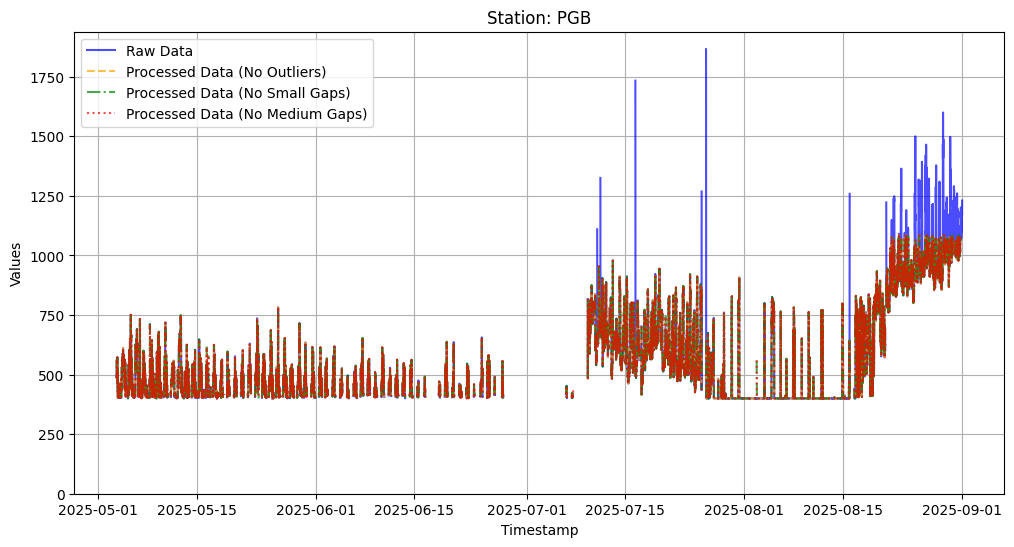

NaN values at different processing stages:
     Before Processing  After Outlier Processing  After Short Gap Processing  After Medium Gap Processing
ICA               6913                      6913                        6598                         6419
TEM               6913                      6913                        6598                         6419
HUM               6913                      6913                        6598                         6419
CO2               6913                      7003                        6702                         6528
VOC               6913                      7147                        6824                         6656


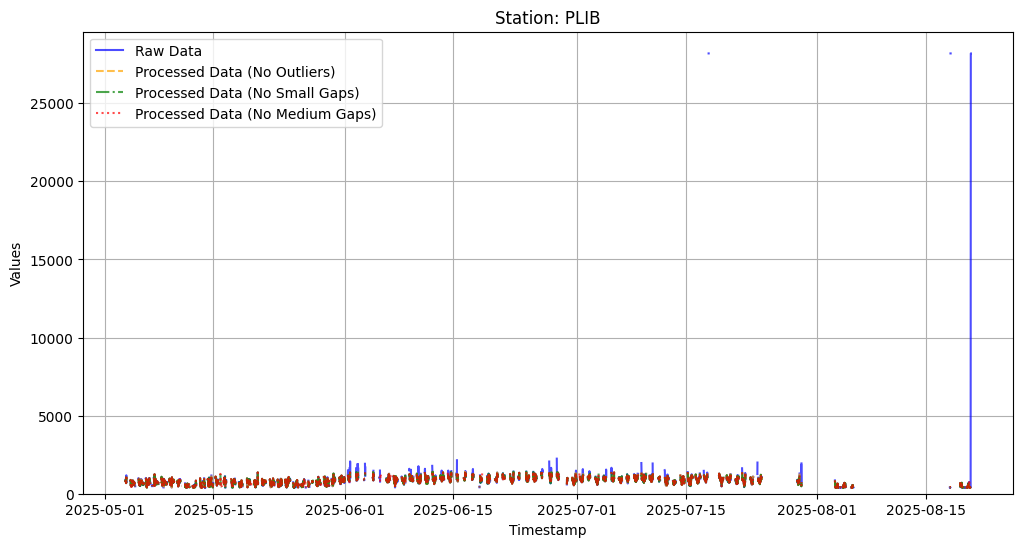

NaN values at different processing stages:
     Before Processing  After Outlier Processing  After Short Gap Processing  After Medium Gap Processing
ICA               4336                      4905                        4603                         4436
CO2               4336                      4364                        4258                         4219
VOC               4336                      4755                        4509                         4396
TEM               4336                      4339                        4247                         4216
HUM               4336                      4338                        4248                         4217


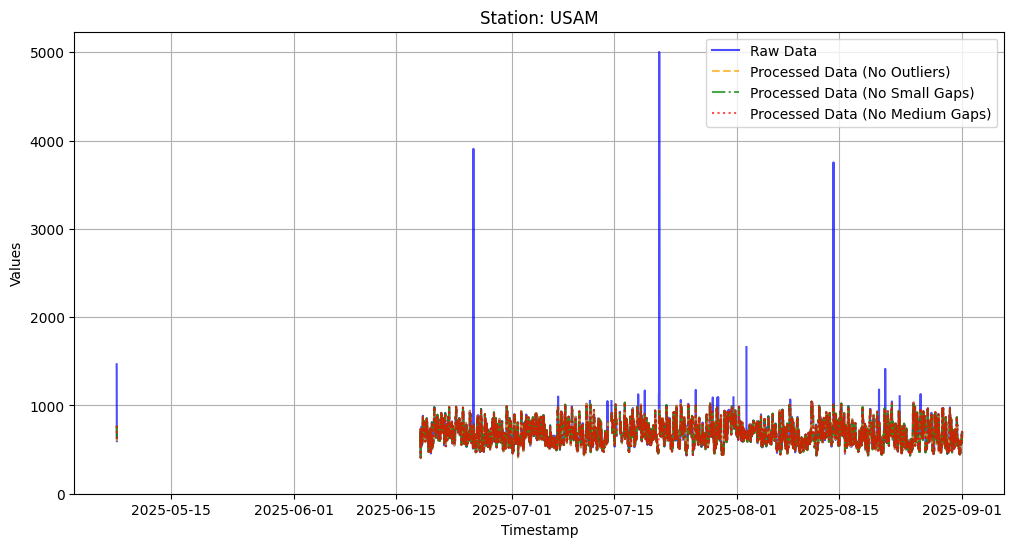

NaN values at different processing stages:
     Before Processing  After Outlier Processing  After Short Gap Processing  After Medium Gap Processing
ICA               4263                      4318                        4300                         4284
TEM               4263                      4287                        4274                         4257
HUM               4263                      4263                        4250                         4237
CO2               4263                      4371                        4333                         4300
VOC               4263                      4835                        4724                         4611


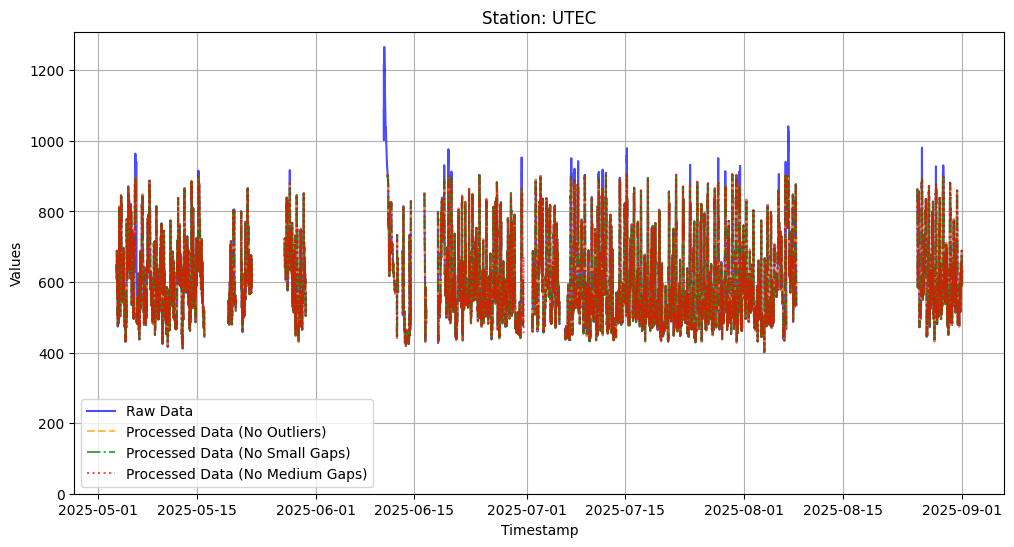

In [199]:
FREQ = pd.Timedelta("15min")
MAX_SHORT = 2   # 2 samples x 15 min = 30 min
MAX_MEDIUM = 4   # 4 samples x 15 min = 60 min

# Load data
stations = ['PGB', 'PLIB', 'USAM', 'UTEC']
generalpath = "data/air/consolidated"
output_path = "data/air/processed"

os.makedirs(output_path, exist_ok=True)  # Ensure output directory exists

for station in stations:

    filepath = os.path.join(generalpath, f"{station}.csv")
    df = pd.read_csv(filepath, delimiter=";", parse_dates=['Timestamp'], index_col='Timestamp')
    raw = df.resample(FREQ).mean()  # Resample to 15-minute intervals

    processed_no_outlier = process_outliers(raw)

    # Mask gaps under the limit for short gaps
    short_gap_mask = mask_gaps(processed_no_outlier, min_len=0, max_len=MAX_SHORT)

    # Fill short gaps using the mask
    processed_no_gap_short = processed_no_outlier.where(~short_gap_mask, fill_short_gaps(processed_no_outlier, max_len=MAX_SHORT))

    # Mask gaps under the limit for medium gaps
    medium_gap_mask = mask_gaps(processed_no_outlier, min_len=MAX_SHORT, max_len=MAX_MEDIUM)
    processed_no_gap_medium = impute_medium_gaps(processed_no_gap_short, medium_gap_mask, window=WINDOW)

    # Save processed data as CSV and Parquet
    processed_no_gap_medium.to_csv(os.path.join(output_path, f"{station}_processed.csv"))
    processed_no_gap_medium.to_parquet(os.path.join(output_path, f"{station}_processed.parquet"))

    pd.set_option('display.max_columns', None)  # Ensure all columns are displayed
    pd.set_option('display.width', 1000)       # Set a wide display width

    nan_counts = pd.DataFrame({
        "Before Processing": raw.isna().sum(),
        "After Outlier Processing": processed_no_outlier.isna().sum(),
        "After Short Gap Processing": processed_no_gap_short.isna().sum(),
        "After Medium Gap Processing": processed_no_gap_medium.isna().sum()
    })

    print("NaN values at different processing stages:")
    print(nan_counts)

       # Plot raw, processed_no_outlier, and processed_no_gap
    plot_dataframes(
        [raw, processed_no_outlier, processed_no_gap_short, processed_no_gap_medium],
        station=station,
        column='CO2',
        labels=['Raw Data', 'Processed Data (No Outliers)', 'Processed Data (No Small Gaps)', 'Processed Data (No Medium Gaps)']
    )

PGB
ICA    4462
TEM    3878
HUM    3878
CO2    4093
VOC    4880
dtype: int64


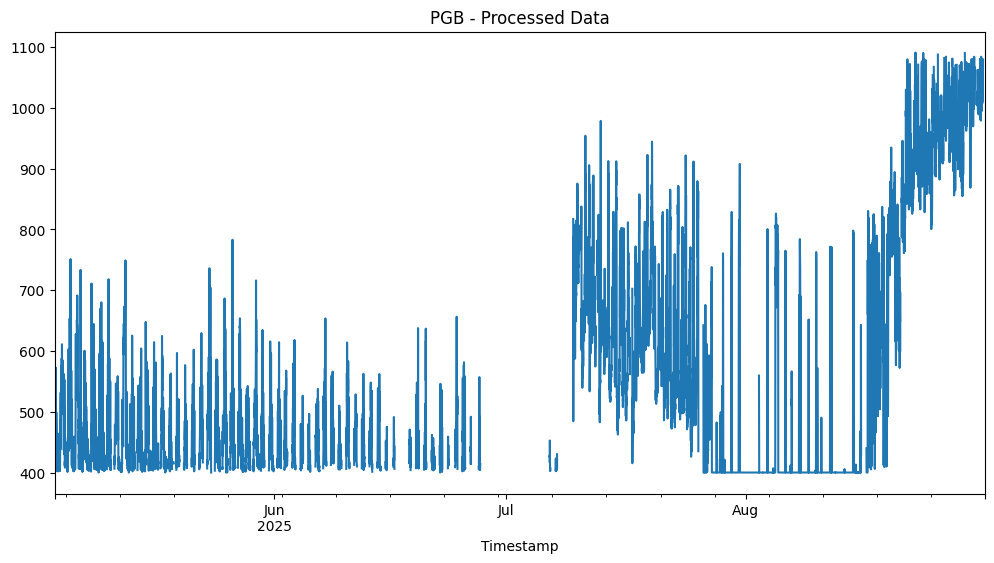

PLIB
ICA    6419
TEM    6419
HUM    6419
CO2    6528
VOC    6656
dtype: int64


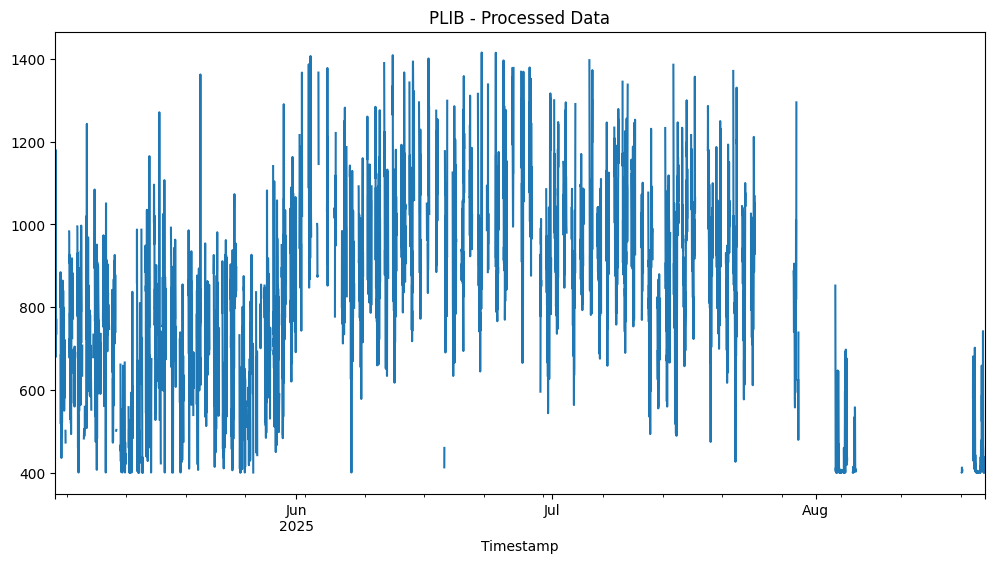

USAM
ICA    4436
CO2    4219
VOC    4396
TEM    4216
HUM    4217
dtype: int64


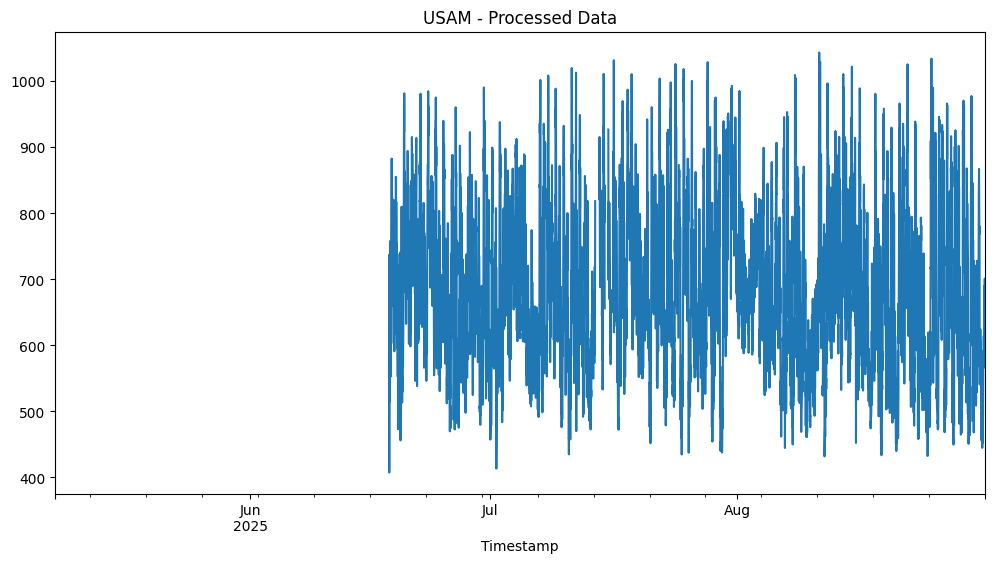

UTEC
ICA    4284
TEM    4257
HUM    4237
CO2    4300
VOC    4611
dtype: int64


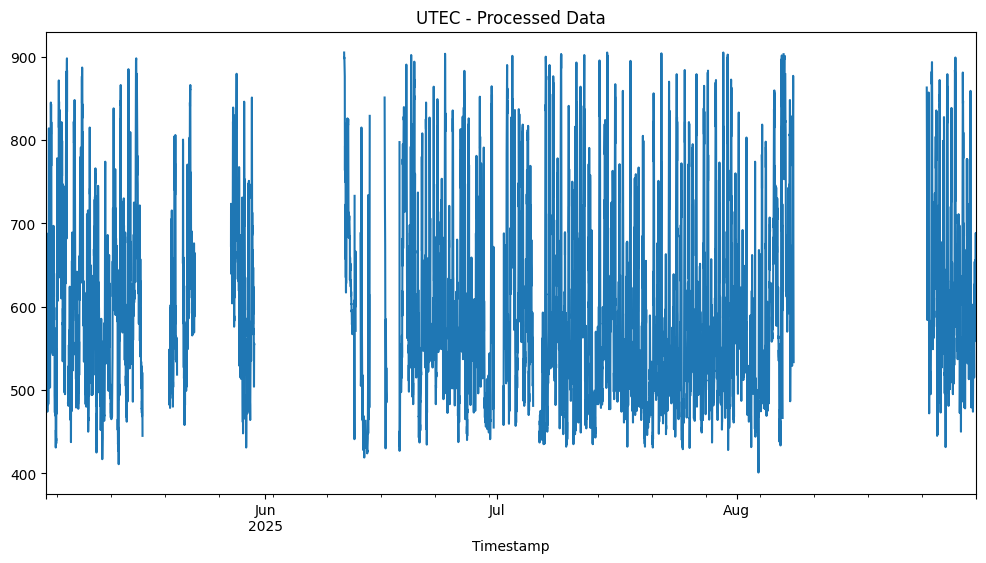

In [174]:
# Load data
stations = ['PGB', 'PLIB', 'USAM', 'UTEC']
generalpath =  "data/air/processed"

for station in stations:

    filepath = os.path.join(generalpath, f"{station}_processed.parquet")
    df_parquet = pd.read_parquet(filepath)
    print(station)
    print(df_parquet.isna().sum())

    # Plot raw, processed_no_outlier, and processed_no_gap
    df_parquet['CO2'].plot(title=f"{station} - Processed Data", figsize=(12, 6))
    plt.show()


PGB
Timestamp       0
ICA          4462
TEM          3878
HUM          3878
CO2          4093
VOC          4880
dtype: int64


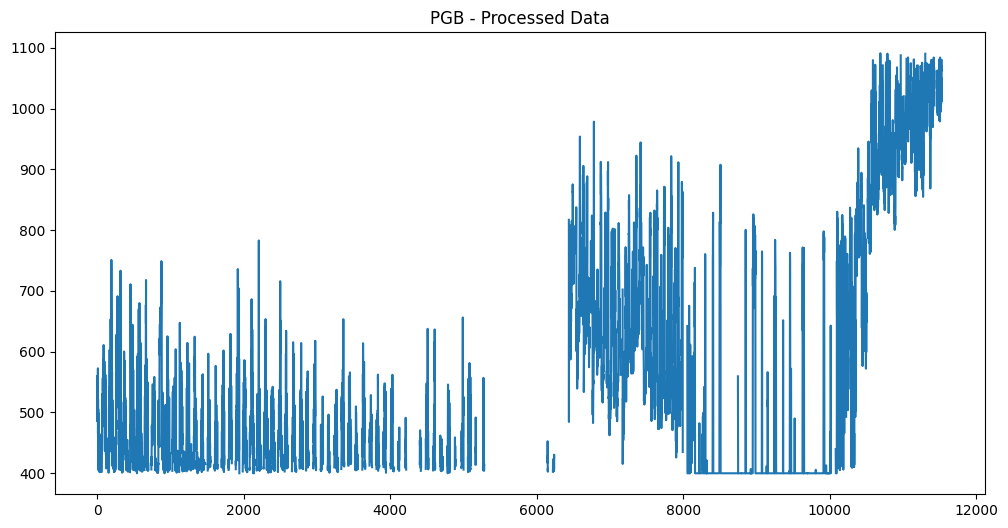

PLIB
Timestamp       0
ICA          6419
TEM          6419
HUM          6419
CO2          6528
VOC          6656
dtype: int64


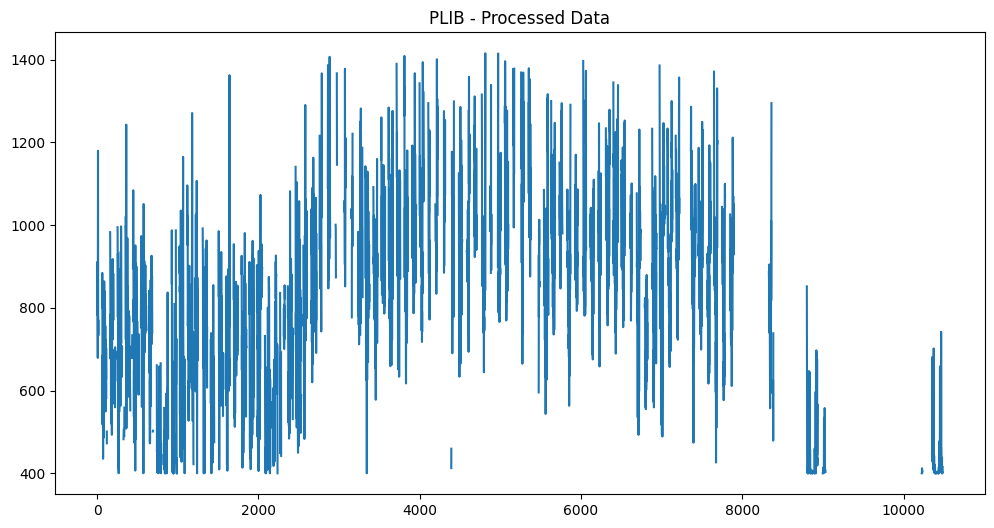

USAM
Timestamp       0
ICA          4436
CO2          4219
VOC          4396
TEM          4216
HUM          4217
dtype: int64


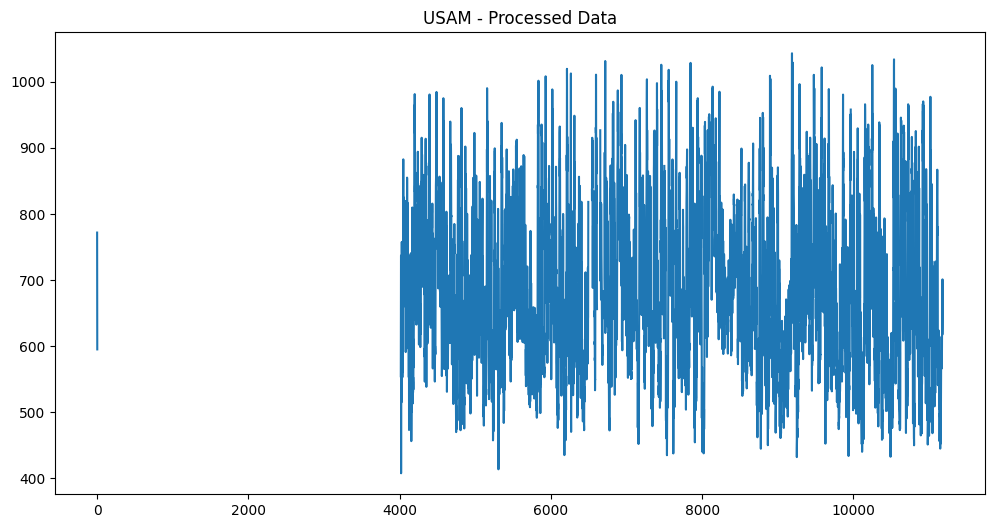

UTEC
Timestamp       0
ICA          4284
TEM          4257
HUM          4237
CO2          4300
VOC          4611
dtype: int64


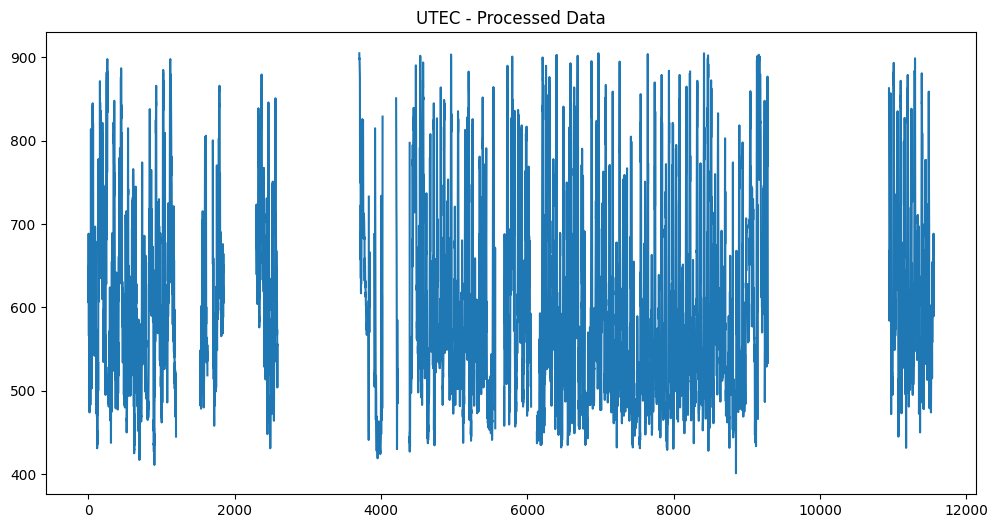

In [178]:
# Load data
stations = ['PGB', 'PLIB', 'USAM', 'UTEC']
generalpath =  "data/air/processed"

for station in stations:

    filepath = os.path.join(generalpath, f"{station}_processed.csv")
    df_csv = pd.read_csv(filepath)
    print(station)
    print(df_csv.isna().sum())

    # Plot raw, processed_no_outlier, and processed_no_gap
    df_csv['CO2'].plot(title=f"{station} - Processed Data", figsize=(12, 6))
    plt.show()